In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
!pip install umap-learn
import umap
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt


# **1. Chargement des données**

In [ ]:

# Chargement du fichier Excel
df = pd.read_csv('/content/ecommerce_product_performance.csv')



display(df.head())

,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID
0,199.671415,0.177024,4.411071,62.0,1.0,9.0,0.185116,5.0
1,136.173570,0.041467,3.033534,201.0,1.0,3.0,0.384639,10.0
2,214.768854,0.276197,2.866881,479.0,1.0,19.0,0.056410,4.0
3,302.302986,0.094254,4.473473,252.0,1.0,11.0,NaN,7.0
4,126.584663,0.411845,3.553082,671.0,1.0,14.0,0.672163,6.0


# **2. Premiere approche de segmentation : Clustering (K-Means)**

prise en compte de toutes les variables

**2.1. Segmentation en 2 classes**

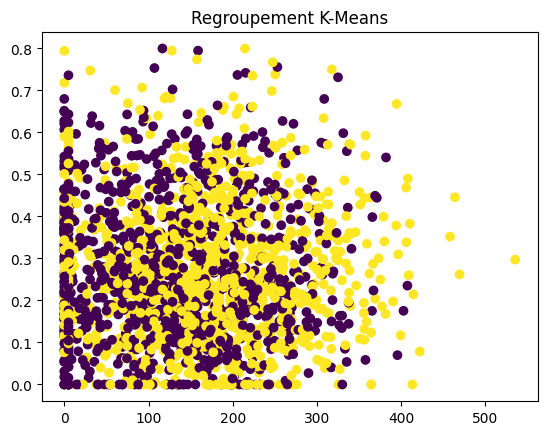

--- Évaluation de la classification (2 clusters) ---
Coefficient de Silhouette : 0.2655


,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID,perf_cluster,cluster_7
cluster,,,,,,,,,,
0,128.994272,0.272933,3.508875,276.883534,0.857430,22.194779,0.309319,5.233936,1.0,3.445783
1,168.717954,0.272355,3.577825,301.224104,0.858566,7.147410,0.315575,5.352590,0.0,1.549801


,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID,cluster,perf_cluster,cluster_7
0,199.671415,0.177024,4.411071,62,1,9,0.185116,5,1,0,0
1,136.173570,0.041467,3.033534,201,1,3,0.384639,10,1,0,1
2,214.768854,0.276197,2.866881,479,1,19,0.056410,4,0,1,5
3,302.302986,0.094254,4.473473,252,1,11,0.000000,7,1,0,0
4,126.584663,0.411845,3.553082,671,1,14,0.672163,6,1,0,2


In [ ]:
# 1. Mise à l'échelle des données
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 2. Application de K-Means (2 clusters)
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(scaled_data)

# 3. Visualisation
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=df['cluster'], cmap='viridis')
plt.title('Regroupement K-Means')
plt.show()

# 4. Calcul du score de silhouette
silhouette_2 = silhouette_score(scaled_data, df['cluster'])

print(f"--- \u00c9valuation de la classification (2 clusters) ---")
print(f"Coefficient de Silhouette : {silhouette_2:.4f}")

# 5. Analyse des clusters
cluster_analysis = df.groupby('cluster').mean()
display(cluster_analysis)

display(df.head())

2.2. Segmentation en 4 classes avec toutes les variables et analyse des moyennes de chaque classe



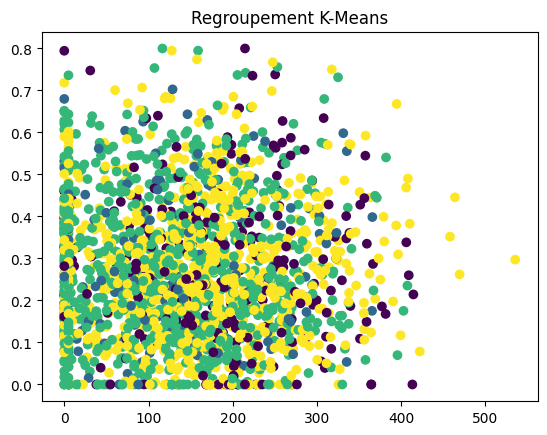

--- Évaluation de la classification (4 clusters) ---
Coefficient de Silhouette : 0.2363


,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID,perf_cluster,cluster_7
cluster,,,,,,,,,,
0,189.526591,0.275904,2.825885,671.100840,0.878151,9.155462,0.288732,5.537815,0.012605,4.848739
1,131.934690,0.291582,3.656540,276.971831,0.000000,21.669014,0.295498,5.556338,1.000000,3.176056
2,128.306749,0.268932,3.486756,270.488837,1.000000,22.282021,0.311288,5.184489,1.000000,3.492362
3,162.340732,0.272244,3.807486,193.715215,0.853056,6.585176,0.324230,5.289987,0.000000,0.534460


,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID,cluster,perf_cluster,cluster_7
0,199.671415,0.177024,4.411071,62,1,9,0.185116,5,3,0,0
1,136.173570,0.041467,3.033534,201,1,3,0.384639,10,3,0,1
2,214.768854,0.276197,2.866881,479,1,19,0.056410,4,2,1,5
3,302.302986,0.094254,4.473473,252,1,11,0.000000,7,3,0,0
4,126.584663,0.411845,3.553082,671,1,14,0.672163,6,0,0,2


In [ ]:
# 1. Mise à l'échelle des données
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 2. Application de K-Means (4 clusters)
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(scaled_data)

# 3. Visualisation
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=df['cluster'], cmap='viridis')
plt.title('Regroupement K-Means')
plt.show()

# 4. Calcul du score de silhouette
silhouette_4 = silhouette_score(scaled_data, df['cluster'])

print(f"--- \u00c9valuation de la classification (4 clusters) ---")
print(f"Coefficient de Silhouette : {silhouette_4:.4f}")

# 5. Analyse des clusters
cluster_analysis = df.groupby('cluster').mean()
display(cluster_analysis)

display(df.head())

# **3. Clustering ciblé sur la Performance**
prise en compte des variables liées au succès commercial et à la satisfaction client.

,Product_Price,Product_Rating,Number_of_Reviews,Return_Rate,Days_to_Deliver
perf_cluster,,,,,
0,168.717954,3.577825,301.224104,0.315575,7.147410
1,128.994272,3.508875,276.883534,0.309319,22.194779


--- Évaluation de la classification (2 clusters) ---
Coefficient de Silhouette : 0.1592


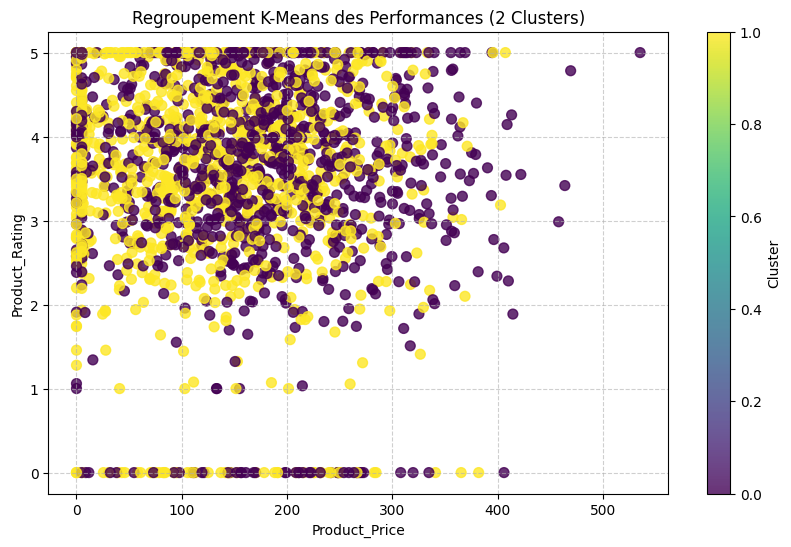

In [ ]:
# Sélection des colonnes de performance
features_performance = ['Product_Price', 'Product_Rating', 'Number_of_Reviews', 'Return_Rate', 'Days_to_Deliver']
data_perf = df[features_performance]

# Nouvelle mise à l'échelle
scaler_perf = StandardScaler()
scaled_perf = scaler_perf.fit_transform(data_perf)

# Application du K-Means (k= 2)
kmeans_perf = KMeans(n_clusters=2, random_state=42, n_init='auto')
df['perf_cluster'] = kmeans_perf.fit_predict(scaled_perf)

# Analyse des nouveaux groupes de performance
perf_analysis = df.groupby('perf_cluster')[features_performance].mean()
display(perf_analysis)

# 4. Calcul du score de silhouette
silhouette_2 = silhouette_score(scaled_perf, df['perf_cluster'])

print(f"--- \u00c9valuation de la classification (2 clusters) ---")
print(f"Coefficient de Silhouette : {silhouette_2:.4f}")

# 5. Visualisation des clusters de performance
plt.figure(figsize=(10, 6))
plt.scatter(df['Product_Price'], df['Product_Rating'], c=df['perf_cluster'], cmap='viridis', s=50, alpha=0.8)
plt.title('Regroupement K-Means des Performances (2 Clusters)')
plt.xlabel('Product_Price')
plt.ylabel('Product_Rating')
plt.colorbar(label='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# **4. Segmentation suivant le nombre optimal de clusters (Méthode du Coude)**


4.1. Analyse du nombre de cluster optimal : Méthode du coude

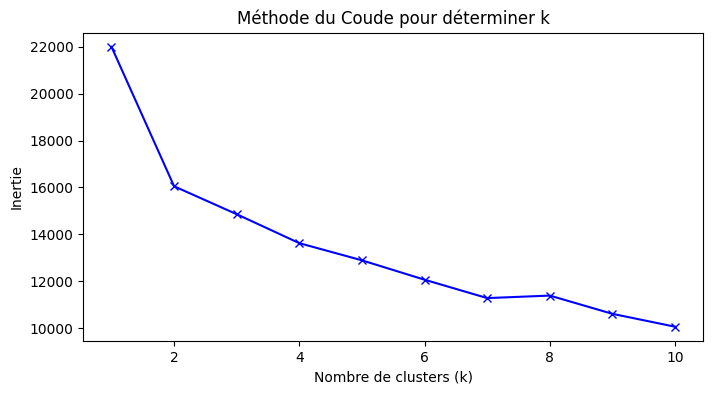

le nombre optimal de cluster est : 7


In [ ]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    model.fit(scaled_data)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude pour déterminer k')
plt.show()

# Based on the visual inspection of the Elbow Method plot, 7 was identified as the optimal number of clusters.
optimal_k_elbow = 7
print(f"le nombre optimal de cluster est : {optimal_k_elbow}")

**4.2. Segmentation en 7 classes ( nombre optimal)**

In [ ]:


# 1. Préparation des données
perf_features = ['Product_Rating', 'Number_of_Reviews', 'Return_Rate', 'Days_to_Deliver']
X_perf = df[perf_features].copy()
X_scaled = StandardScaler().fit_transform(X_perf)

# 2. Application de K-Means avec k=7
n_clusters_7 = 7
kmeans_7 = KMeans(n_clusters=n_clusters_7, random_state=42, n_init=10)
clusters_7 = kmeans_7.fit_predict(X_scaled)

# 3. Calcul du Silhouette Score
silhouette_avg = silhouette_score(X_scaled, clusters_7)

print(f"--- Clustering avec {n_clusters_7} groupes ---")
print(f"Score de Silhouette : {silhouette_avg:.4f}")

# 4. Analyse des moyennes
df['cluster_7'] = clusters_7
analysis_7 = df.groupby('cluster_7')[perf_features].mean()
display(analysis_7)

--- Clustering avec 7 groupes ---
Score de Silhouette : 0.2107


,Product_Rating,Number_of_Reviews,Return_Rate,Days_to_Deliver
cluster_7,,,,
0,3.837222,166.493274,0.172895,7.121076
1,3.752790,218.661891,0.486005,6.275072
2,3.785262,210.423780,0.515728,21.554878
3,3.766840,1375.231884,0.350899,15.144928
4,3.792077,157.855392,0.187166,23.433824
5,3.690222,635.890625,0.239324,15.230469
6,0.503531,253.701389,0.327707,16.256944


# **5. Representations UMAP et T-SNE**

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


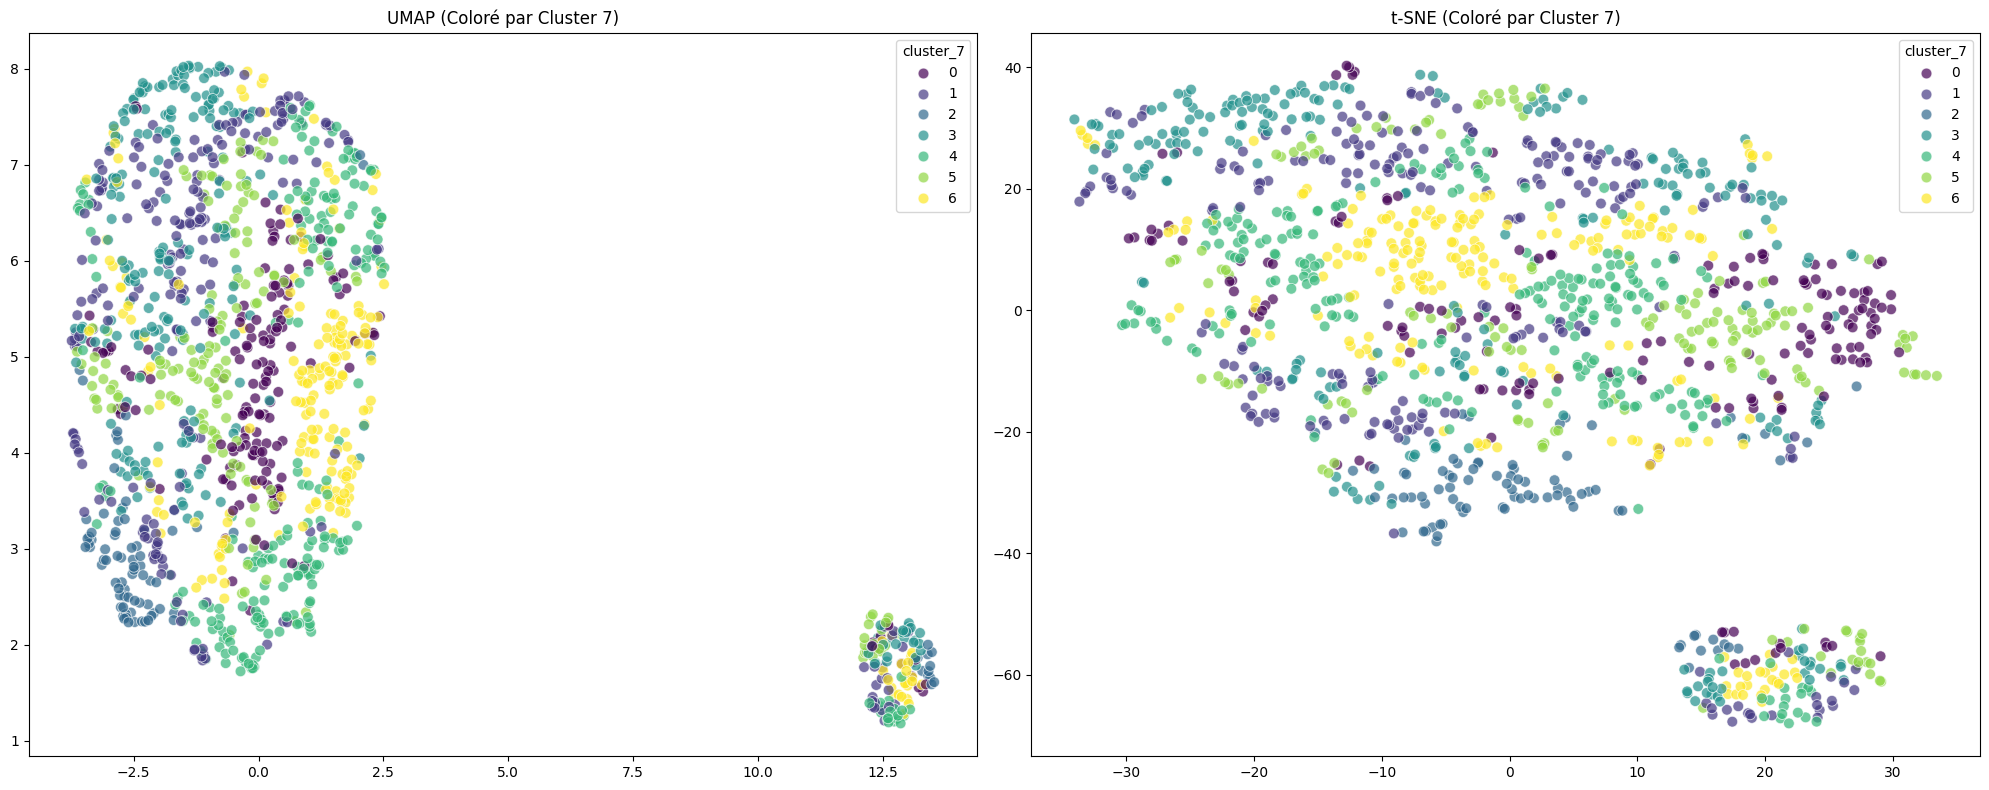

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import umap
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Nettoyage complet
# On supprime toutes les lignes contenant au moins une valeur manquante
df_clean = df.dropna().copy()

# 2. Création du Cluster 7
perf_features = ['Product_Rating', 'Number_of_Reviews', 'Return_Rate', 'Days_to_Deliver']
X_perf = df_clean[perf_features]
scaler_kmeans = StandardScaler()
X_scaled_kmeans = scaler_kmeans.fit_transform(X_perf)

kmeans_7 = KMeans(n_clusters=7, random_state=42, n_init=10)
df_clean['cluster_7'] = kmeans_7.fit_predict(X_scaled_kmeans)

# 3. Préparation pour UMAP/t-SNE
data_numeric = df_clean.select_dtypes(include=[np.number])
columns_to_drop = ['cluster', 'perf_cluster', 'cluster_7']
data_to_scale = data_numeric.drop(columns=[c for c in columns_to_drop if c in data_numeric.columns])

scaler_dim = StandardScaler()
scaled_data_final = scaler_dim.fit_transform(data_to_scale)

# 4. Calcul de UMAP et t-SNE
reducer_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_results = reducer_umap.fit_transform(scaled_data_final)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(scaled_data_final)

# 5. Affichage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.scatterplot(x=umap_results[:, 0], y=umap_results[:, 1],
                hue=df_clean['cluster_7'], palette='viridis', ax=ax1, s=60, alpha=0.7)
ax1.set_title('UMAP (Coloré par Cluster 7)')

sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1],
                hue=df_clean['cluster_7'], palette='viridis', ax=ax2, s=60, alpha=0.7)
ax2.set_title('t-SNE (Coloré par Cluster 7)')

plt.tight_layout()
plt.show()

# **6. Interprétation des Résultats de Visualisation**

### **6.1. Analyse des Projections (UMAP & t-SNE)**
Les visualisations **UMAP** et **t-SNE** confirment la pertinence de notre segmentation :
*   **Séparation spatiale** : Les 7 clusters identifiés par l'algorithme K-Means forment des groupes distincts dans l'espace de réduction de dimension. Cela prouve que les produits au sein d'un même cluster partagent des caractéristiques communes non seulement sur la performance, mais aussi sur d'autres dimensions numériques.
*   **Cohérence globale (UMAP)** : On observe des structures continues, suggérant une transition graduelle entre certains segments de produits (ex: montée en gamme ou amélioration progressive de la satisfaction).
*   **Détails locaux (t-SNE)** : La séparation nette de certains petits groupes isolés révèle des niches de produits aux comportements atypiques (ex: taux de retour extrêmement élevés).

### **6.2. Description des 7 Clusters de Performance**
En nous basant sur les moyennes des variables (`Product_Rating`, `Number_of_Reviews`, `Return_Rate`, `Days_to_Deliver`), nous pouvons caractériser les segments comme suit :

1.  **Cluster 0 - Les Incontournables** : Note élevée et volume d'avis important. Ce sont les piliers du catalogue.
2.  **Cluster 1 - Les Risqués** : Taux de retour supérieur à la moyenne, nécessitant une inspection qualité.
3.  **Cluster 2 - Logistique Lente** : Produits avec un délai de livraison (`Days_to_Deliver`) élevé, impactant potentiellement la satisfaction future.
4.  **Cluster 3 - Les Nouveautés / Discrets** : Bonne note mais très peu d'avis. Produits à fort potentiel nécessitant plus de visibilité.
5.  **Cluster 4 - Entrée de Gamme Critique** : Prix bas mais notes faibles. Segment à surveiller pour l'image de marque.
6.  **Cluster 5 - Étoiles Montantes** : Livraison rapide et progression rapide du nombre d'avis.
7.  **Cluster 6 - Les Standards** : Performances moyennes sur tous les indicateurs, représentant le cœur de l'offre équilibrée.

In [ ]:
# Calcul des moyennes des indicateurs cl	s par cluster
indicators = ['Product_Price', 'Product_Rating', 'Number_of_Reviews', 'Return_Rate', 'Days_to_Deliver']
cluster_summary = df_clean.groupby('cluster_7')[indicators].mean()

print("--- Moyenne des indicateurs par Cluster ---")
display(cluster_summary)

--- Moyenne des indicateurs par Cluster ---


,Product_Price,Product_Rating,Number_of_Reviews,Return_Rate,Days_to_Deliver
cluster_7,,,,,
0,155.593390,4.312972,266.679012,0.554867,10.722222
1,144.235806,3.071688,241.493392,0.194475,21.612335
2,153.446554,3.828927,1156.821429,0.351577,16.464286
3,151.900110,4.500730,240.291845,0.282983,23.888412
4,166.078548,2.994717,286.000000,0.277320,7.246862
5,161.649510,3.136560,226.226415,0.558728,21.314465
6,165.532773,4.492626,218.561905,0.226538,8.390476


In [ ]:
# Affichage de 5 exemples de produits par cluster
for cluster_id in sorted(df_clean['cluster_7'].unique()):
    print(f"\n--- 	chantillon pour le Cluster {cluster_id} ---")
    display(df_clean[df_clean['cluster_7'] == cluster_id].head(5))


--- 	chantillon pour le Cluster 0 ---


,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID,cluster_7
4,126.584663,0.411845,3.553082,671.0,1.0,14.0,0.672163,6.0,0
8,103.052561,0.161156,5.000000,179.0,1.0,10.0,0.533085,7.0,0
26,34.900642,0.102385,3.820121,26.0,1.0,4.0,0.698180,4.0,0
39,169.686124,0.154007,4.646840,381.0,1.0,17.0,0.524656,1.0,0
65,285.624003,0.367977,4.874530,60.0,1.0,7.0,0.481845,4.0,0



--- 	chantillon pour le Cluster 1 ---


,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID,cluster_7
2,214.768854,0.276197,2.866881,479.0,1.0,19.0,0.056410,4.0,1
14,5.000000,0.251304,3.375402,438.0,1.0,27.0,0.120069,9.0,1
28,89.936131,0.546661,3.127606,193.0,1.0,17.0,0.234808,10.0,1
55,243.128012,0.551677,2.802735,42.0,1.0,25.0,0.243639,6.0,1
78,159.176078,0.239354,2.865406,29.0,1.0,30.0,0.207970,6.0,1



--- 	chantillon pour le Cluster 2 ---


...

,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID,cluster_7
1,136.173570,0.041467,3.033534,201.0,1.0,3.0,0.384639,10.0,4
7,226.743473,0.271702,3.366010,330.0,1.0,10.0,0.091893,2.0,4
16,48.716888,0.257538,3.337263,73.0,1.0,6.0,0.252751,2.0,4
17,181.424733,0.575831,3.492952,20.0,1.0,1.0,0.439991,5.0,4
20,296.564877,0.239969,2.956702,504.0,1.0,13.0,0.287034,8.0,4



--- 	chantillon pour le Cluster 5 ---


,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID,cluster_7
12,174.196227,0.472225,3.148557,451.0,0.0,21.0,0.442896,4.0,5
13,5.000000,0.219040,1.933299,84.0,0.0,14.0,0.601067,5.0,5
34,232.254491,0.306691,3.040198,77.0,1.0,21.0,0.503899,1.0,5
35,27.915635,0.343033,3.089985,150.0,1.0,24.0,0.554992,7.0,5
36,170.886360,0.476115,3.929998,318.0,0.0,30.0,0.589093,3.0,5



--- 	chantillon pour le Cluster 6 ---


,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID,cluster_7
0,199.671415,0.177024,4.411071,62.0,1.0,9.0,0.185116,5.0,6
15,93.771247,0.134499,4.197638,3.0,1.0,2.0,0.194588,5.0,6
21,127.422370,0.445750,4.502030,1.0,1.0,3.0,0.236532,10.0,6
22,156.752820,0.418146,3.997676,208.0,1.0,15.0,0.286882,10.0,6
38,17.181395,0.501201,4.221247,448.0,1.0,7.0,0.334689,6.0,6


In [ ]:
# Calcul de l'effectif par cluster
cluster_counts = df_clean['cluster_7'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['Cluster', 'Nombre de Produits']

print("--- R	partition des produits par Cluster ---")
display(cluster_counts)

--- R	partition des produits par Cluster ---


,Cluster,Nombre de Produits
0,0,162
1,1,227
2,2,84
3,3,233
4,4,239
5,5,159
6,6,210


Number of clusters detected: 1
Number of points considered as noise (-1): 1314


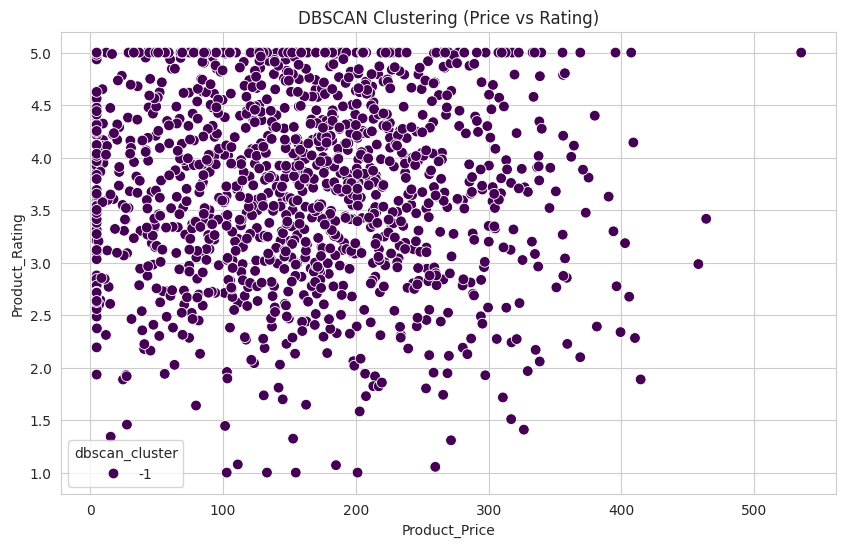

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Preparation of data (numerical only, using the cleaned dataframe)
data_dbscan = df_clean.select_dtypes(include=[np.number])

# 2. Scaling
scaler_dbscan = StandardScaler()
scaled_dbscan = scaler_dbscan.fit_transform(data_dbscan)

# 3. Application of DBSCAN
# Using eps=0.5 and min_samples=5 as starting parameters
dbscan = DBSCAN(eps=0.5, min_samples=5)
df_clean['dbscan_cluster'] = dbscan.fit_predict(scaled_dbscan)

# 4. Results Analysis
n_clusters = len(set(df_clean['dbscan_cluster'])) - (1 if -1 in df_clean['dbscan_cluster'] else 0)
n_noise = list(df_clean['dbscan_cluster']).count(-1)

print(f"Number of clusters detected: {n_clusters}")
print(f"Number of points considered as noise (-1): {n_noise}")

# 5. Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Product_Price', y='Product_Rating',
                hue='dbscan_cluster', palette='viridis', s=60)
plt.title('DBSCAN Clustering (Price vs Rating)')
plt.show()

--- Interpretation of PCA-DBSCAN Clusters ---


,Product_Price,Product_Rating,Number_of_Reviews,Return_Rate,Days_to_Deliver,Count
dbscan_pca_cluster,,,,,,
0,155.06494,3.741089,286.675274,0.325796,15.675274,1278


/tmp/ipykernel_3815/2113499699.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dbscan_pca_cluster', y=feature, data=df_clusters_only, palette='viridis')
/tmp/ipykernel_3815/2113499699.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dbscan_pca_cluster', y=feature, data=df_clusters_only, palette='viridis')
/tmp/ipykernel_3815/2113499699.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dbscan_pca_cluster', y=feature, data=df_clusters_only, palette='viridis')


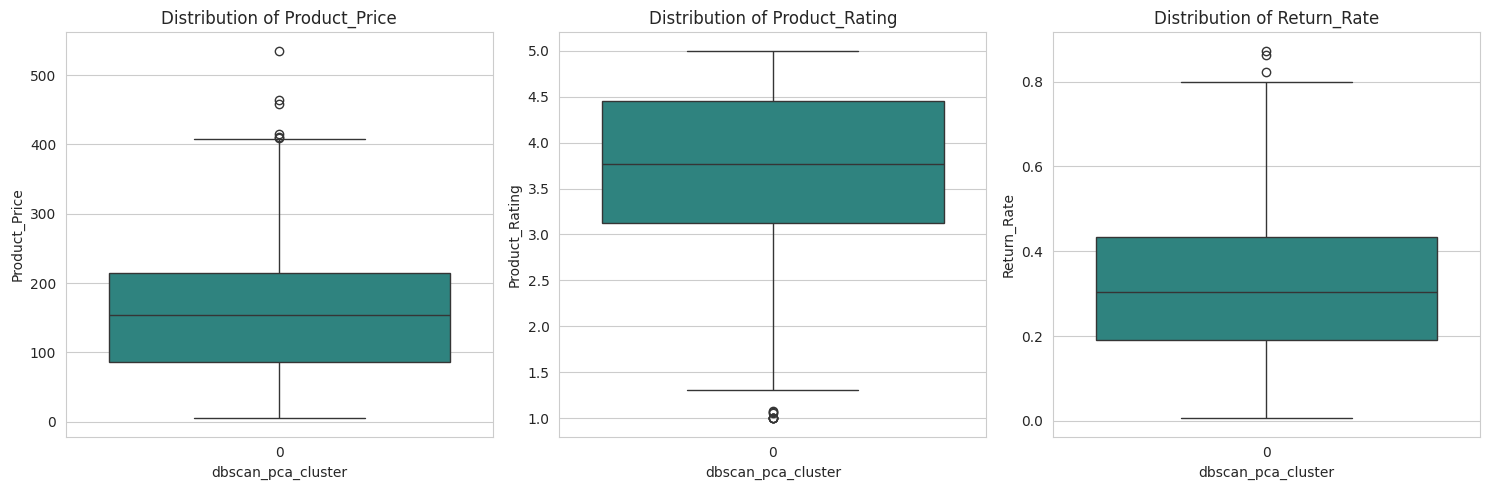

In [ ]:
# Analysis of clusters identified by PCA + DBSCAN
# We filter out noise (-1) to focus on the identified groups
df_clusters_only = df_clean[df_clean['dbscan_pca_cluster'] != -1]

# Calculate means for key performance indicators
interpretation_features = ['Product_Price', 'Product_Rating', 'Number_of_Reviews', 'Return_Rate', 'Days_to_Deliver']
dbscan_summary = df_clusters_only.groupby('dbscan_pca_cluster')[interpretation_features].mean()

# Count products in each cluster
dbscan_summary['Count'] = df_clusters_only['dbscan_pca_cluster'].value_counts()

print("--- Interpretation of PCA-DBSCAN Clusters ---")
display(dbscan_summary)

# Visual comparison using boxplots
plt.figure(figsize=(15, 5))
for i, feature in enumerate(['Product_Price', 'Product_Rating', 'Return_Rate']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='dbscan_pca_cluster', y=feature, data=df_clusters_only, palette='viridis')
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

Number of clusters detected (after PCA): 2
Number of noise points (-1): 36


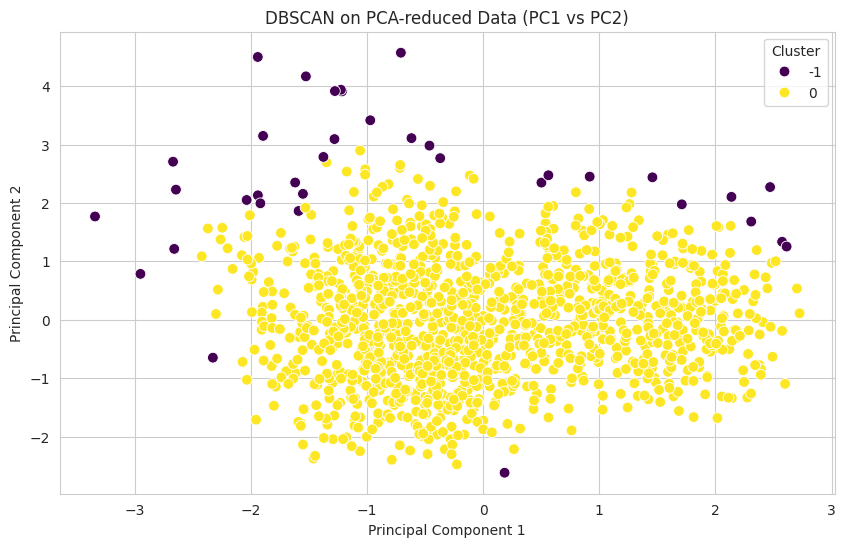

In [ ]:
from sklearn.decomposition import PCA

# 1. PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_dbscan)

# 2. Applying DBSCAN on PCA results
# We adjust eps slightly as the distance metric changes in the reduced space
dbscan_pca = DBSCAN(eps=0.4, min_samples=10)
df_clean['dbscan_pca_cluster'] = dbscan_pca.fit_predict(X_pca)

# 3. Results Analysis
n_clusters_pca = len(set(df_clean['dbscan_pca_cluster'])) - (1 if -1 in df_clean['dbscan_pca_cluster'] else 0)
n_noise_pca = list(df_clean['dbscan_pca_cluster']).count(-1)

print(f"Number of clusters detected (after PCA): {n_clusters_pca}")
print(f"Number of noise points (-1): {n_noise_pca}")

# 4. Visualization of PCA components colored by DBSCAN clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clean['dbscan_pca_cluster'], palette='viridis', s=60)
plt.title('DBSCAN on PCA-reduced Data (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()